# **Pipeline for $k_{app}$** calculation

This notebook exemplifies the pipeline for the calculation of the apparent *in vivo* turnover number $k_{app}$ of *E. coli*. 

In [59]:
# automatic module reloading
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cobra

cobra.Configuration().solver = "cplex" 

# Add paths
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../scripts'))

# Add directories
data_dir = "../data"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Create enzymes dataframe

In [60]:
# Module imports
from scripts.enzyme_classifier import create_gpr_dataframe, analyze_model_gprs

from cobra.io import read_sbml_model
import cobra 

# Load the model
model_path = os.path.join(data_dir, "raw", "GEMs", "iML1515_GEM.xml")
model = read_sbml_model(model_path)

# Create a dataframe of the GPR rules
df_enzymes = create_gpr_dataframe(model)

# Print stats of the model
stats = analyze_model_gprs(model)
print(f"\nModel Stats:")
print(f"Total reactions: {stats['total_reactions']}")
print(f"Reactions with GPR: {stats['reactions_with_gpr']}")
print(f"Total genes: {stats['total_genes']}")
print(f"GPR cases: {stats['gpr_complexity']}")
df_enzymes.head()


Model Stats:
Total reactions: 2712
Reactions with GPR: 2266
Total genes: 1516
GPR cases: {'simple': 1302, 'or_only': 651, 'and_only': 221, 'complex': 92}


,gene,type,rxn,subsystem,subunit,GPR,enzyme_ID,gpr_class
0,b2551,isoenzyme,ALATA_D2,Cofactor and Prosthetic Group Biosynthesis,-,b2551 or b0870,b2551_i_ALATA_D2,or_only
1,b0870,isoenzyme,ALATA_D2,Cofactor and Prosthetic Group Biosynthesis,-,b2551 or b0870,b0870_i_ALATA_D2,or_only
2,b3368,homomeric,SHCHD2,Cofactor and Prosthetic Group Biosynthesis,-,b3368,b3368_h_SHCHD2,simple
3,b2436,homomeric,CPPPGO,Cofactor and Prosthetic Group Biosynthesis,-,b2436,b2436_h_CPPPGO,simple
4,b3500,homomeric,GTHOr,Cofactor and Prosthetic Group Biosynthesis,-,b3500,b3500_h_GTHOr,simple


## 2. Get fluxomics from FBA simulations across multiple conditions

In [61]:
from scripts.kapp_builder import create_fluxomics_dataframe

fluxomics_df = create_fluxomics_dataframe(flux_method='pFBA', GEM=model, 
                                         carbon_uptake=[2, 6, 10], 
                                         oxygen_uptake=[15, 17.5, 20])


Processing condition 1: Carbon=2, Oxygen=15
Condition 1 completed successfully
Processing condition 2: Carbon=2, Oxygen=17.5
Condition 2 completed successfully
Processing condition 3: Carbon=2, Oxygen=20
Condition 3 completed successfully
Processing condition 4: Carbon=6, Oxygen=15
Condition 4 completed successfully
Processing condition 5: Carbon=6, Oxygen=17.5
Condition 5 completed successfully
Processing condition 6: Carbon=6, Oxygen=20
Condition 6 completed successfully
Processing condition 7: Carbon=10, Oxygen=15
Condition 7 completed successfully
Processing condition 8: Carbon=10, Oxygen=17.5
Condition 8 completed successfully
Processing condition 9: Carbon=10, Oxygen=20
Condition 9 completed successfully
Fluxomics dataframe created with 9 conditions


In [62]:
flux_summary = fluxomics_df.set_index("rxn_id").agg(["mean", "std", "min", "max"], axis=1)

## 3. Merge fluxomics to enzyme, substrate, and sequence data

In [63]:
from scripts.kapp_builder import create_enzyme_info_dataframe

substrates_df = os.path.join(data_dir, "processed", "kinGEMs_iML1515", "iML1515_substrates.csv")
sequence_df = os.path.join(data_dir, "processed", "UniProt", "iML1515_E coli_83333_UniProt.csv")

enzymes_info_dfs = create_enzyme_info_dataframe(df_enzymes, fluxomics_df, substrates_df, sequence_df)

Processing 9 flux conditions...
Processing flux_cond1...
Rows before filtering: 4624
Completed flux_cond1: 1157 rows after filtering
Processing flux_cond2...
Rows before filtering: 4624
Completed flux_cond2: 1147 rows after filtering
Processing flux_cond3...
Rows before filtering: 4624
Completed flux_cond3: 1147 rows after filtering
Processing flux_cond4...
Rows before filtering: 4624
Completed flux_cond4: 1145 rows after filtering
Processing flux_cond5...
Rows before filtering: 4624
Completed flux_cond5: 1149 rows after filtering
Processing flux_cond6...
Rows before filtering: 4624
Completed flux_cond6: 1149 rows after filtering
Processing flux_cond7...
Rows before filtering: 4624
Completed flux_cond7: 1134 rows after filtering
Processing flux_cond8...
Rows before filtering: 4624
Completed flux_cond8: 1144 rows after filtering
Processing flux_cond9...
Rows before filtering: 4624
Completed flux_cond9: 1144 rows after filtering
Created enzyme info dataframes for 9 conditions


`enzymes_info_dfs` is a dict storing all dataframes for each of the conditions created.

An example of how each  of these dfs look:

In [64]:
enzymes_info_dfs['flux_cond1'].head()

,gene,type,rxn,subsystem,subunit,GPR,enzyme_ID,gpr_class,rxn_id,flux_value,Reaction,SMILES,Direction,model_gene_id,uniprot_id,ec_number,sequence
4,b3368,homomeric,SHCHD2,Cofactor and Prosthetic Group Biosynthesis,-,b3368,b3368_h_SHCHD2,simple,SHCHD2,0.000035,SHCHD2,C[C@@]1(CC(=O)[O-])/C2=C/c3[nH]c(c(CCC(=O)[O-]...,forward,b3368,CYSG_ECOLI,1.3.1.76; 2.1.1.107; 4.99.1.4,MDHLPIFCQLRDRDCLIVGGGDVAERKARLLLDAGARLTVNALAFI...
5,b3368,homomeric,SHCHD2,Cofactor and Prosthetic Group Biosynthesis,-,b3368,b3368_h_SHCHD2,simple,SHCHD2,0.000035,SHCHD2,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)([O-])OP(...,forward,b3368,CYSG_ECOLI,1.3.1.76; 2.1.1.107; 4.99.1.4,MDHLPIFCQLRDRDCLIVGGGDVAERKARLLLDAGARLTVNALAFI...
6,b2436,homomeric,CPPPGO,Cofactor and Prosthetic Group Biosynthesis,-,b2436,b2436_h_CPPPGO,simple,CPPPGO,0.000035,CPPPGO,Cc1c2[nH]c(c1CCC(=O)[O-])Cc1[nH]c(c(CCC(=O)[O-...,forward,b2436,HEM6_ECOLI,1.3.3.3,MKPDAHQVKQFLLNLQDTICQQLTAVDGAEFVEDSWQREAGGGGRS...
34,b3916,homomeric,PFK_3,Pentose Phosphate Pathway,-,b3916,b3916_h_PFK_3,simple,PFK_3,0.013822,PFK_3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,forward,b3916,PFKA_ECOLI,2.7.1.11,MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLY...
35,b3916,homomeric,PFK_3,Pentose Phosphate Pathway,-,b3916,b3916_h_PFK_3,simple,PFK_3,0.013822,PFK_3,O=C(CO)[C@@H](O)[C@H](O)[C@H](O)[C@H](O)COP(=O...,forward,b3916,PFKA_ECOLI,2.7.1.11,MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLY...


## 3. Map proteomics

In [65]:
from scripts.kapp_builder import process_enzyme_protein_mapping

paxdb_dir = os.path.join(data_dir, "raw", "PaxDb","511145_ecoli","511145-WHOLE_ORGANISM-integrated.txt")

enzyme_protein_info_dfs = process_enzyme_protein_mapping(enzymes_info_dfs, paxdb_dir, p_total=[0.32, 0.435, 0.55])


Loading PaxDB data from: ../data\raw\PaxDb\511145_ecoli\511145-WHOLE_ORGANISM-integrated.txt
PaxDB data loaded: 4094 rows
Processing 9 conditions × 3 p_total values = 27 combinations

Processing condition: flux_cond1
  Processing p_total=0.32 (1/27)
    Success: 1157 rows, 1152 with protein data
  Processing p_total=0.435 (2/27)
    Success: 1157 rows, 1152 with protein data
  Processing p_total=0.55 (3/27)
    Success: 1157 rows, 1152 with protein data

Processing condition: flux_cond2
  Processing p_total=0.32 (4/27)
    Success: 1147 rows, 1142 with protein data
  Processing p_total=0.435 (5/27)
    Success: 1147 rows, 1142 with protein data
  Processing p_total=0.55 (6/27)
    Success: 1147 rows, 1142 with protein data

Processing condition: flux_cond3
  Processing p_total=0.32 (7/27)
    Success: 1147 rows, 1142 with protein data
  Processing p_total=0.435 (8/27)
    Success: 1147 rows, 1142 with protein data
  Processing p_total=0.55 (9/27)
    Success: 1147 rows, 1142 with prote

Example of how a df w proteomics looks:

In [66]:
# Stored with double index: condition, p_total
condition = 'flux_cond1'
p_total_val = 0.32
enzyme_protein_info_dfs[condition][p_total_val].head()

,gene,type,rxn,subsystem,subunit,GPR,enzyme_ID,gpr_class,rxn_id,flux_value,...,Direction,model_gene_id,uniprot_id,ec_number,sequence,protein_ppm,molecular_weight,protein_fraction,protein_mol_gdcw,protein_mmol_gdcw
0,b3368,homomeric,SHCHD2,Cofactor and Prosthetic Group Biosynthesis,-,b3368,b3368_h_SHCHD2,simple,SHCHD2,0.000035,...,forward,b3368,CYSG_ECOLI,1.3.1.76; 2.1.1.107; 4.99.1.4,MDHLPIFCQLRDRDCLIVGGGDVAERKARLLLDAGARLTVNALAFI...,18.9,49950.8154,0.000019,1.210791e-10,1.210791e-07
1,b3368,homomeric,SHCHD2,Cofactor and Prosthetic Group Biosynthesis,-,b3368,b3368_h_SHCHD2,simple,SHCHD2,0.000035,...,forward,b3368,CYSG_ECOLI,1.3.1.76; 2.1.1.107; 4.99.1.4,MDHLPIFCQLRDRDCLIVGGGDVAERKARLLLDAGARLTVNALAFI...,18.9,49950.8154,0.000019,1.210791e-10,1.210791e-07
2,b2436,homomeric,CPPPGO,Cofactor and Prosthetic Group Biosynthesis,-,b2436,b2436_h_CPPPGO,simple,CPPPGO,0.000035,...,forward,b2436,HEM6_ECOLI,1.3.3.3,MKPDAHQVKQFLLNLQDTICQQLTAVDGAEFVEDSWQREAGGGGRS...,13.8,34322.2093,0.000014,1.286630e-10,1.286630e-07
3,b3916,homomeric,PFK_3,Pentose Phosphate Pathway,-,b3916,b3916_h_PFK_3,simple,PFK_3,0.013822,...,forward,b3916,PFKA_ECOLI,2.7.1.11,MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLY...,904.0,34841.6643,0.000904,8.302703e-09,8.302703e-06
4,b3916,homomeric,PFK_3,Pentose Phosphate Pathway,-,b3916,b3916_h_PFK_3,simple,PFK_3,0.013822,...,forward,b3916,PFKA_ECOLI,2.7.1.11,MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLY...,904.0,34841.6643,0.000904,8.302703e-09,8.302703e-06


## 4. Calculate $k_{app}$ homomeric

In [67]:
from scripts.kapp_builder import calculate_kapp_homomeric

kapp_dfs = calculate_kapp_homomeric(enzyme_protein_info_dfs)


Processing condition: flux_cond1
  Processing p_total=0.32
    Rows before filtering homomeric: 1157
    Rows after filtering homomeric: 444
    Rows before filtering duplicates: 444
    Rows after filtering duplicates: 414
    Calculated kcat_app for 407 enzymes
  Processing p_total=0.435
    Rows before filtering homomeric: 1157
    Rows after filtering homomeric: 444
    Rows before filtering duplicates: 444
    Rows after filtering duplicates: 414
    Calculated kcat_app for 407 enzymes
  Processing p_total=0.55
    Rows before filtering homomeric: 1157
    Rows after filtering homomeric: 444
    Rows before filtering duplicates: 444
    Rows after filtering duplicates: 414
    Calculated kcat_app for 407 enzymes

Processing condition: flux_cond2
  Processing p_total=0.32
    Rows before filtering homomeric: 1147
    Rows after filtering homomeric: 442
    Rows before filtering duplicates: 442
    Rows after filtering duplicates: 414
    Calculated kcat_app for 407 enzymes
  Proce

In [68]:
# Stored with double index: condition, p_total
condition = 'flux_cond1'
p_total_val = 0.32
kapp_dfs[condition][p_total_val].head()

,gene,type,rxn,subsystem,subunit,GPR,enzyme_ID,gpr_class,rxn_id,flux_value,...,uniprot_id,ec_number,sequence,protein_ppm,molecular_weight,protein_fraction,protein_mol_gdcw,protein_mmol_gdcw,flux_value_per_sec,kcat_app
0,b3368,homomeric,SHCHD2,Cofactor and Prosthetic Group Biosynthesis,-,b3368,b3368_h_SHCHD2,simple,SHCHD2,0.000035,...,CYSG_ECOLI,1.3.1.76; 2.1.1.107; 4.99.1.4,MDHLPIFCQLRDRDCLIVGGGDVAERKARLLLDAGARLTVNALAFI...,18.9,49950.8154,0.000019,1.210791e-10,1.210791e-07,9.586235e-09,0.079173
1,b3368,homomeric,SHCHD2,Cofactor and Prosthetic Group Biosynthesis,-,b3368,b3368_h_SHCHD2,simple,SHCHD2,0.000035,...,CYSG_ECOLI,1.3.1.76; 2.1.1.107; 4.99.1.4,MDHLPIFCQLRDRDCLIVGGGDVAERKARLLLDAGARLTVNALAFI...,18.9,49950.8154,0.000019,1.210791e-10,1.210791e-07,9.586235e-09,0.079173
2,b2436,homomeric,CPPPGO,Cofactor and Prosthetic Group Biosynthesis,-,b2436,b2436_h_CPPPGO,simple,CPPPGO,0.000035,...,HEM6_ECOLI,1.3.3.3,MKPDAHQVKQFLLNLQDTICQQLTAVDGAEFVEDSWQREAGGGGRS...,13.8,34322.2093,0.000014,1.286630e-10,1.286630e-07,9.586235e-09,0.074507
3,b3916,homomeric,PFK_3,Pentose Phosphate Pathway,-,b3916,b3916_h_PFK_3,simple,PFK_3,0.013822,...,PFKA_ECOLI,2.7.1.11,MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLY...,904.0,34841.6643,0.000904,8.302703e-09,8.302703e-06,3.839478e-06,0.462437
4,b3916,homomeric,PFK_3,Pentose Phosphate Pathway,-,b3916,b3916_h_PFK_3,simple,PFK_3,0.013822,...,PFKA_ECOLI,2.7.1.11,MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLY...,904.0,34841.6643,0.000904,8.302703e-09,8.302703e-06,3.839478e-06,0.462437


## 5. Filter values above physical threshold

In [70]:
from scripts.kapp_builder import evaluate_kapp_homomeric

kapp_dfs = evaluate_kapp_homomeric(kapp_dfs)

Filtering kcat_app values outside range: 1e-04 to 1e+06 s⁻¹

Processing condition: flux_cond1
  Processing p_total=0.32
    Original rows: 401
    Filtered rows: 401
    Removed total: 0 (high: 0, low: 0)
  Processing p_total=0.435
    Original rows: 401
    Filtered rows: 401
    Removed total: 0 (high: 0, low: 0)
  Processing p_total=0.55
    Original rows: 401
    Filtered rows: 401
    Removed total: 0 (high: 0, low: 0)

Processing condition: flux_cond2
  Processing p_total=0.32
    Original rows: 398
    Filtered rows: 398
    Removed total: 0 (high: 0, low: 0)
  Processing p_total=0.435
    Original rows: 398
    Filtered rows: 398
    Removed total: 0 (high: 0, low: 0)
  Processing p_total=0.55
    Original rows: 398
    Filtered rows: 398
    Removed total: 0 (high: 0, low: 0)

Processing condition: flux_cond3
  Processing p_total=0.32
    Original rows: 398
    Filtered rows: 398
    Removed total: 0 (high: 0, low: 0)
  Processing p_total=0.435
    Original rows: 398
    Filte

## 6. Get $k_{max}$

In [73]:
from scripts.kapp_builder import get_kmax_homomeric

kmax_results = get_kmax_homomeric(kapp_dfs)

Starting kmax analysis across all conditions and p_total values...
  Added 394 valid entries from flux_cond1, p_total=0.32
  Added 394 valid entries from flux_cond1, p_total=0.435
  Added 394 valid entries from flux_cond1, p_total=0.55
  Added 391 valid entries from flux_cond2, p_total=0.32
  Added 391 valid entries from flux_cond2, p_total=0.435
  Added 391 valid entries from flux_cond2, p_total=0.55
  Added 391 valid entries from flux_cond3, p_total=0.32
  Added 391 valid entries from flux_cond3, p_total=0.435
  Added 391 valid entries from flux_cond3, p_total=0.55
  Added 396 valid entries from flux_cond4, p_total=0.32
  Added 396 valid entries from flux_cond4, p_total=0.435
  Added 396 valid entries from flux_cond4, p_total=0.55
  Added 392 valid entries from flux_cond5, p_total=0.32
  Added 392 valid entries from flux_cond5, p_total=0.435
  Added 392 valid entries from flux_cond5, p_total=0.55
  Added 392 valid entries from flux_cond6, p_total=0.32
  Added 392 valid entries from f

In [74]:
kmax_results.head()

,sequence,SMILES,kcat_app_max,condition_max,p_total_max,gene,rxn,flux_value,protein_mmol_gdcw,subsystem
0,MMITLRKLPLAVAVAAGVMSAQAMAVDFHGYARSGIGWTGSGGEQQ...,O=C[C@H](O)[C@@H](O)[C@H](O)[C@H](O)CO,4332.607908,flux_cond7,0.32,b4036,GLCtex_copy1,10.000000,6.411330e-07,"Transport, Outer Membrane"
1,MDFSLTEEQELLLASIRELITTNFPEEYFRTCDQNGTYPREFMRAL...,C/C=C/C(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)...,3857.579892,flux_cond9,0.32,b1695,ACOAD1fr,0.292461,2.105965e-08,Membrane Lipid Metabolism
2,MDFSLTEEQELLLASIRELITTNFPEEYFRTCDQNGTYPREFMRAL...,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,3857.579892,flux_cond9,0.32,b1695,ACOAD1fr,0.292461,2.105965e-08,Membrane Lipid Metabolism
3,MPNITWCDLPEDVSLWPGLPLSLSGDEVMPLDYHAGRSGWLLYGRG...,[NH3+][C@@H](COP(=O)([O-])[O-])C(=O)[O-],1997.321299,flux_cond9,0.32,b4388,PSP_L,1.411713,1.963342e-07,Glycine and Serine Metabolism
4,MLKYRLISAFVLIPVVIAALFLLPPVGFAIVTLVVCMLAAWEWGQL...,CCCCCCC=CCCCCCCCC(=O)OCC(COP(=O)([O-])O)OC(=O)...,646.603533,flux_cond9,0.32,b0175,DASYN161,0.061811,2.655358e-08,Glycerophospholipid Metabolism


In [75]:
#kmax_results.to_csv(os.path.join(data_dir, "final", "kmax", "iml1515_homomeric_kmax.csv"), index=False)
kmax_results.to_csv(os.path.join(data_dir, "results", "kmax", "iml1515_homomeric_kmax_pFBA.csv"), index=False)

## 7. Comparison against in vitro

In [76]:
from scripts.kcat_utils import load_kcat_dataset_ecoli

kmax_dir = os.path.join(data_dir, "results", "kmax", "iml1515_homomeric_kmax_pFBA.csv")
CPIPred_dir = os.path.join(data_dir, "raw", "CPIPred", "CPI_kcat_scrn.csv")
CatPred_dir = os.path.join(data_dir, "raw", "CatPred", "kcat-random_trainvaltest.csv")
EnzyExtract_dir = os.path.join(data_dir, "raw", "EnzyExtract", "EnzyExtractDB_176463.parquet")

df_kmax = pd.read_csv(kmax_dir)

df_cpi, df_catpred, df_enzyextract = load_kcat_dataset_ecoli(CPIPred_dir, CatPred_dir, EnzyExtract_dir)

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat in vivo    kcat in vitro  
--------------------------------------------------
Count                370             1,327          
Mean                 8.03e+01        7.23e+03       
Median               1.11e+01        1.43e+01       
Std Dev              3.82e+02        6.32e+04       
P10                  5.00e-02        1.20e-01       
P25                  3.53e-01        1.40e+00       
P75                  3.26e+01        9.20e+01       
P90                  1.33e+02        7.50e+02       
IQR (P25-P75)        3.23e+01        9.06e+01       
Geometric Mean       4.25e+00        1.19e+01       
Geometric Std        2.23e+01        3.60e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat in vivo    kcat in vitro  
--------------------------------------------------
Count        

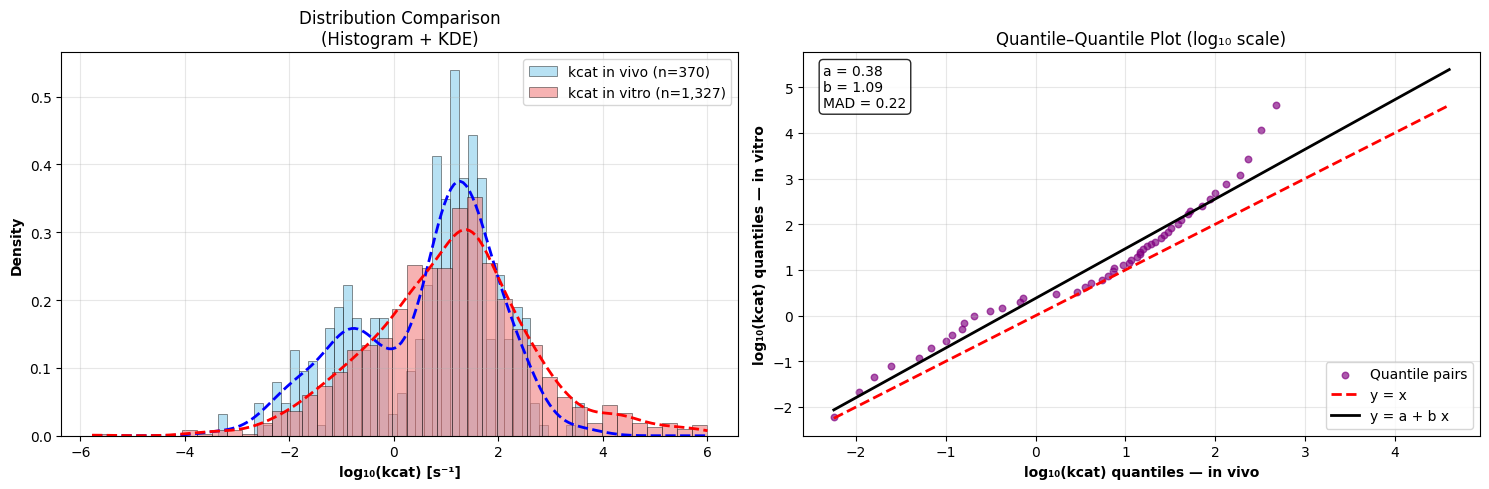

In [77]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_kmax, "kcat_app_max", df_catpred, "kcat_CatPred", label1="kcat in vivo", label2="kcat in vitro")

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kmax_invivo     kcat_CPIPred   
--------------------------------------------------
Count                370             4,504          
Mean                 8.03e+01        4.03e+02       
Median               1.11e+01        5.85e+00       
Std Dev              3.82e+02        1.06e+04       
P10                  5.00e-02        4.21e-02       
P25                  3.53e-01        3.23e-01       
P75                  3.26e+01        9.00e+01       
P90                  1.33e+02        5.10e+02       
IQR (P25-P75)        3.23e+01        8.97e+01       
Geometric Mean       4.25e+00        4.52e+00       
Geometric Std        2.23e+01        3.43e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kmax_invivo     kcat_CPIPred   
--------------------------------------------------
Count        

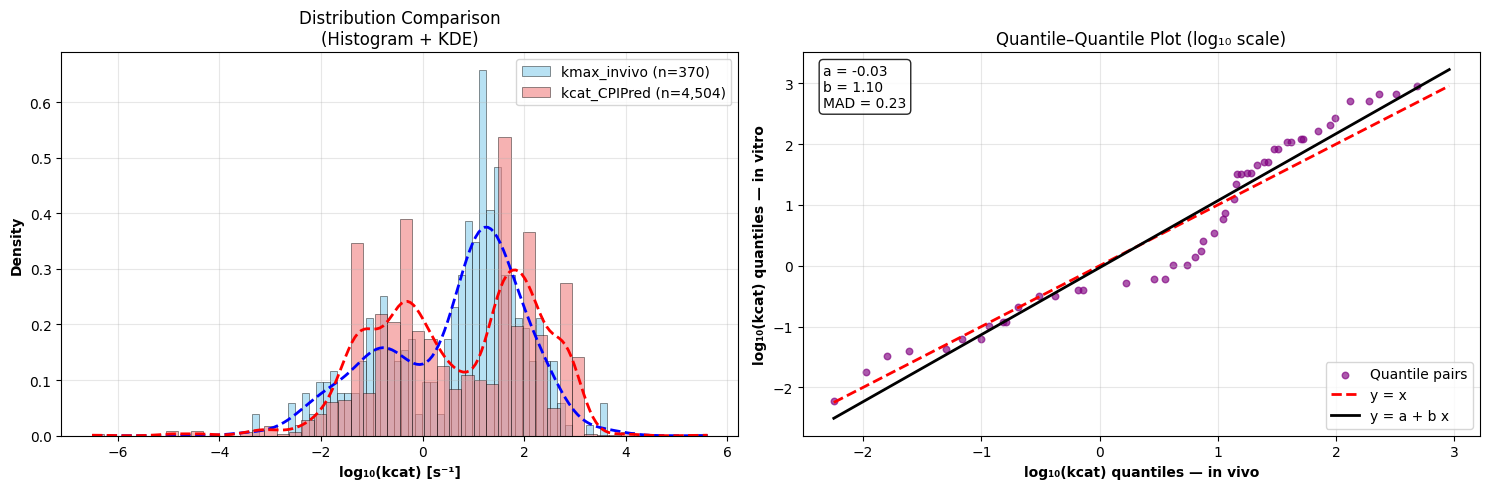

In [78]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_kmax, "kcat_app_max", df_cpi, "kcat_CPIPred", label1="kmax_invivo", label2="kcat_CPIPred")

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat in vivo    kcat EnzyExtract
--------------------------------------------------
Count                370             14,540         
Mean                 8.03e+01        8.45e+03       
Median               1.11e+01        3.33e+00       
Std Dev              3.82e+02        3.65e+05       
P10                  5.00e-02        1.80e-02       
P25                  3.53e-01        2.17e-01       
P75                  3.26e+01        3.20e+01       
P90                  1.33e+02        1.74e+02       
IQR (P25-P75)        3.23e+01        3.18e+01       
Geometric Mean       4.25e+00        2.37e+00       
Geometric Std        2.23e+01        3.85e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat in vivo    kcat EnzyExtract
--------------------------------------------------
Count      

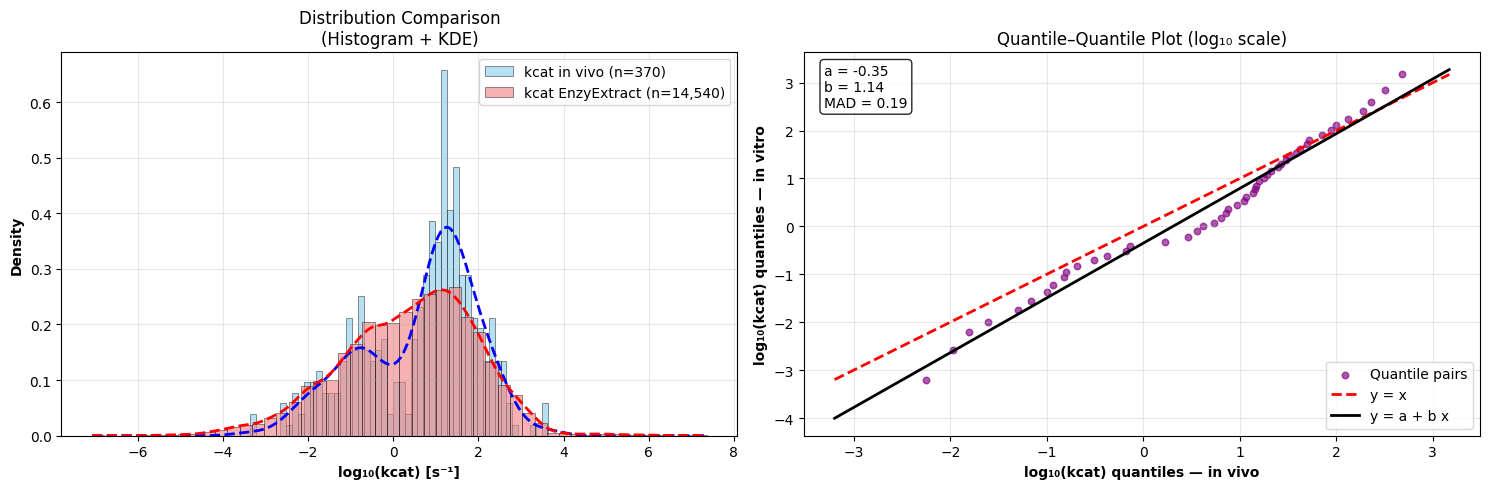

In [79]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_kmax, "kcat_app_max", df_enzyextract, "kcat_EnzyExtract", label1="kcat in vivo", label2="kcat EnzyExtract")

## 8. Correct CatPred comparison
CatPred's SMILES include all of the involved substrates. I clean them to keep the main substrate(s) only, no cofactors, as independent entries. Then these and the in vivo substrates are canonicalized for a correct comparison.

In [80]:
from scripts.kcat_utils import process_catpred_smiles

df_catpred_clean = df_catpred.copy()
df_catpred_clean.rename(columns={"SMILES": "reactant_smiles"}, inplace=True)
df_catpred_clean = process_catpred_smiles(df_catpred_clean)
df_catpred_clean.drop(columns={"reactant_smiles"}, inplace=True)


KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat in vivo    kcat in vitro  
--------------------------------------------------
Count                370             1,579          
Mean                 8.03e+01        7.47e+03       
Median               1.11e+01        1.40e+01       
Std Dev              3.82e+02        6.29e+04       
P10                  5.00e-02        1.28e-01       
P25                  3.53e-01        1.40e+00       
P75                  3.26e+01        9.50e+01       
P90                  1.33e+02        7.72e+02       
IQR (P25-P75)        3.23e+01        9.36e+01       
Geometric Mean       4.25e+00        1.22e+01       
Geometric Std        2.23e+01        3.71e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat in vivo    kcat in vitro  
--------------------------------------------------
Count        

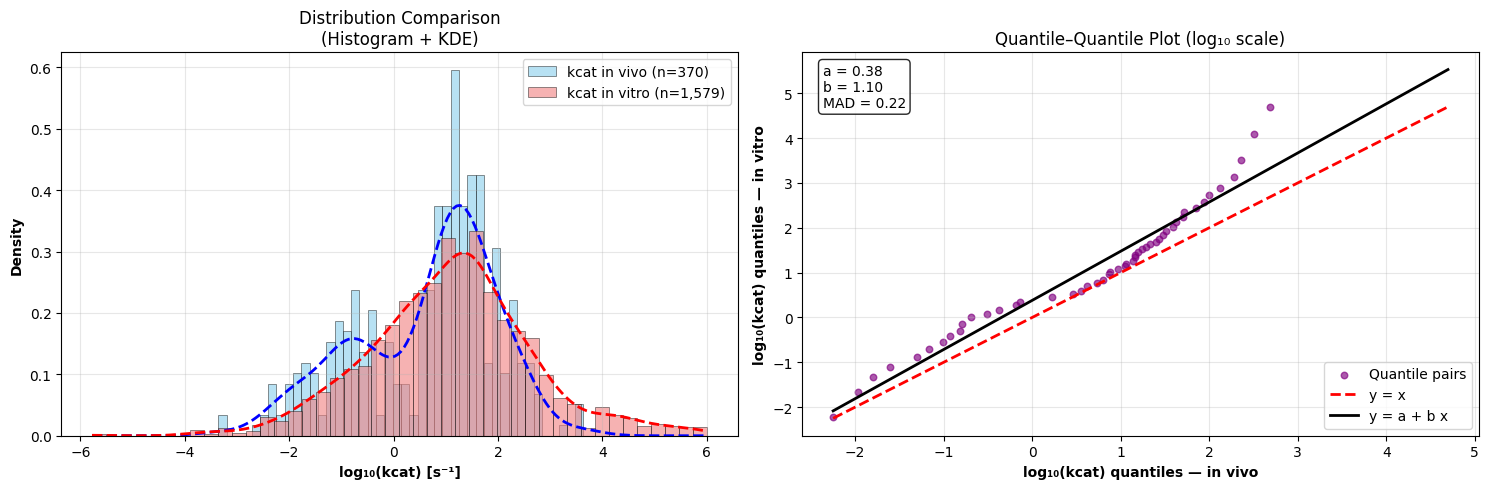

In [81]:
compare_kcat_distribution(df_kmax, "kcat_app_max", df_catpred_clean, "kcat_CatPred", label1="kcat in vivo", label2="kcat in vitro")

In [82]:
df_catpred_clean.to_csv(os.path.join(data_dir, "processed", "CatPred", "catpred_single_subs.csv"), index=False)

In [83]:
# Merge with single substrate
df_kmax_catpred = pd.merge(kmax_results, df_catpred_clean, on=["sequence", "SMILES"], how='left')

# Only 3 matches after merging single substrates, canonicalizing is necessary

In [84]:
from scripts.kcat_utils import canonicalize

df_catpred_clean['SMILES_canon'] = df_catpred_clean['SMILES'].apply(canonicalize)
kmax_results['SMILES_canon'] = kmax_results['SMILES'].apply(canonicalize)

[12:36:11] WARNING: not removing hydrogen atom without neighbors


In [85]:
# Merge with canon
df_kmax_catpred2 = pd.merge(kmax_results, df_catpred_clean, on=["sequence", "SMILES_canon"], how='left')

# Just 4 datapoints merged 

# 9. EnzyExtract analysis

In [86]:
# We'll use the complete dataset for analysis
# This means considering orthologous enzymes - same genes but found in different species

df_enzyextract_complete = pd.read_parquet(EnzyExtract_dir)

In [87]:

from scripts.kcat_utils import canonicalize

df_enzyextract_complete['SMILES_canon'] = df_enzyextract_complete['smiles'].apply(canonicalize)
df_kmax['SMILES_canon'] = df_kmax['SMILES'].apply(canonicalize)

[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not removing hydrogen atom without neighbors
[12:36:15] WARNING: not r

In [88]:
df_merge_enzyextract_canon =  pd.merge(df_kmax, df_enzyextract_complete, on=["sequence", "SMILES_canon"], how='left')

In [89]:
df_merge_enzyextract_canon = df_merge_enzyextract_canon.dropna(subset=['kcat_value'])

In [90]:
import numpy as np

# log transform 
log_kcat_app = np.log10(df_merge_enzyextract_canon['kcat_app_max'])
log_kcat_val = np.log10(df_merge_enzyextract_canon['kcat_value'])

# drop NaNs or -inf from log transform
valid = log_kcat_app.notna() & log_kcat_val.notna() & np.isfinite(log_kcat_app) & np.isfinite(log_kcat_val)

# pearson correlation (r)
r = log_kcat_app[valid].corr(log_kcat_val[valid], method='pearson')
print("Pearson r (log values):", r)

# R2
r2 = r ** 2
print("R2 (log values):", r2)


Pearson r (log values): 0.5124220297514779
R2 (log values): 0.2625763365746245


# [PRELIMINARY $k_{app}$]
*Keeping just for records*

Using fluxomics data matched to the Crown et al. study (E. coli,  W3110, M9+Glu none)

## a. Merge fluxomics information


In [91]:
fba_exp_df = pd.read_csv(os.path.join(data_dir, "results", "ECOMICS", "exp_vs_FBA.csv"))

df_fluxomics_enzymes = pd.merge(
    df_enzymes,
    fba_exp_df,
    left_on="rxn",
    right_on="rxn_id",
    how="left"
)

df_fluxomics_enzymes = df_fluxomics_enzymes.drop(columns=["rxn_id"])

## b. Merge substrate partners
Using dataframe of substrate partners from kinGEMs pipeline

In [31]:
# Load
iML1515_substrates_dir = os.path.join(data_dir, "processed", "kinGEMs_iML1515", "iML1515_substrates.csv")
df_iML1515_substrates = pd.read_csv(iML1515_substrates_dir)

# Keep just Reaction, SMILES and direction column
df_iML1515_substrates = df_iML1515_substrates[['Reaction', 'SMILES', 'Direction']]

In [32]:
# Merge using reaction ID
df_fluxomics_enzymes = pd.merge(
    df_fluxomics_enzymes,
    df_iML1515_substrates,
    left_on="rxn",
    right_on="Reaction",
    how="left"
)

df_fluxomics_enzymes = df_fluxomics_enzymes.drop(columns=["Reaction"])

In [33]:
# Drop rows with wrong direction-flux
df_fluxomics_enzymes = df_fluxomics_enzymes[
    ((df_fluxomics_enzymes['Direction'] == 'forward') & (df_fluxomics_enzymes['FBA_flux'] >= 0)) |
    ((df_fluxomics_enzymes['Direction'] == 'reverse') & (df_fluxomics_enzymes['FBA_flux'] <= 0))
]

print(len(df_fluxomics_enzymes))

10551


In [34]:
# Drop rows with balancing species - these are not substrates
# where SMILES is '[H+]' or 'O'
df_fluxomics_enzymes = df_fluxomics_enzymes[
    ~df_fluxomics_enzymes['SMILES'].isin(['[H+]', 'O'])
]

print(len(df_fluxomics_enzymes))

8588


In [35]:
# even stricter cofactor filtering 

# Define common cofactors to filter out
cofactors = {
    'O',           # water
    'O=O',         # molecular oxygen  
    '[H]',         # hydrogen
    'OO',          # hydrogen peroxide
    '[O]',         # atomic oxygen
    '[OH-]',       # hydroxide
    '[H+]',        # proton
    'N',           # nitrogen (sometimes used)
    'P',           # phosphorus
    'S',           # sulfur
}

df_fluxomics_enzymes = df_fluxomics_enzymes[
    ~df_fluxomics_enzymes['SMILES'].isin(cofactors)
]

print(len(df_fluxomics_enzymes))

8504


In [36]:
# even stricter cofactor filtering 

simple_cofactors = {
    'C(=O)O',      # formic acid
    'CO',          # methanol
    'CCO',         # ethanol
    'CC(=O)O',     # acetic acid
    'C',           # methane
    'CC',          # ethane
    'CCC',         # propane
    'N',           # ammonia (as N)
    'NN',          # hydrazine
    'C=O',         # formaldehyde
    'CC=O',        # acetaldehyde
    'O=C=O',       # carbon dioxide
    '[NH3+]',      # ammonium
    '[Na+]',       # sodium
    '[Cl-]',       # chloride
    '[K+]',        # potassium
    '[Mg+2]',      # magnesium
    '[Ca+2]',      # calcium
}

df_fluxomics_enzymes = df_fluxomics_enzymes[
    ~df_fluxomics_enzymes['SMILES'].isin(simple_cofactors)
]

print(len(df_fluxomics_enzymes))

8393


In [37]:
# Remove rows with 0 FBA flux 
df_fluxomics_enzymes = df_fluxomics_enzymes[df_fluxomics_enzymes['FBA_flux'] != 0]

## c. Add sequences from UniProt

In [38]:
# Read sequences recovered from UniProt
seq_path = os.path.join(data_dir, "processed", 'UniProt', 'iML1515_E coli_83333_UniProt.csv')
seq_df = pd.read_csv(seq_path)

# Create a dictionary of gene-sequence
seq_mapping = seq_df.set_index('model_gene_id')['sequence'].to_dict()

# Map to dataframe
df_fluxomics_enzymes['sequence'] = df_fluxomics_enzymes['gene'].map(seq_mapping)

## d. . Map proteomics from PaxDb

In [39]:
from scripts.paxdb_mapper import map_paxdb_to_gene

# Load PaxDB file
ecoli_paxdb_dir = os.path.join(data_dir,"raw", "PaxDb","511145_ecoli","511145-WHOLE_ORGANISM-integrated.txt")

# Convert to dataframe
ecoli_paxdb = pd.read_csv(
    ecoli_paxdb_dir,
    sep="\t",
    comment="#",
    header=None,
    names=["gene_name", "string_external_id", "abundance"]  # set column names
)

# Map PaxDB abundances to enzymes by gene ID and calculate protein concentrations
# p_total is the total protein content in g/gDCW
df_fluxomics_enzymes = map_paxdb_to_gene(ecoli_paxdb, df_fluxomics_enzymes, p_total=0.55)

## e. Filter dataframe to keep only homomeric enzymes (i.e. 'simple' gpr class)
TO DO: Add isoenzymes and complexes

In [40]:
df_fluxomics_homomeric = df_fluxomics_enzymes[df_fluxomics_enzymes['gpr_class'] == 'simple']

In [41]:
print(f'Length of ALL enzymes df: {len(df_fluxomics_enzymes)}')
print(f'Length of homomeric enzymes df: {len(df_fluxomics_homomeric)}')

Length of ALL enzymes df: 1146
Length of homomeric enzymes df: 441


In [42]:
print(f'Length of homomeric enzymes df before dropping duplicates: {len(df_fluxomics_homomeric)}')

df_fluxomics_homomeric.drop_duplicates(subset=["SMILES", "sequence"])

print(f'Length of homomeric enzymes df after dropping duplicates: {len(df_fluxomics_homomeric)}')


Length of homomeric enzymes df before dropping duplicates: 441
Length of homomeric enzymes df after dropping duplicates: 441


## f. Calculate $k_{app}$

In [43]:
# Convert negative fluxes to positive
df_fluxomics_homomeric.loc[:, 'FBA_flux'] = df_fluxomics_homomeric['FBA_flux'].abs()

# COBRA fluxes are in mmol/gDW*h
df_fluxomics_homomeric.loc[:, 'FBA_flux'] = df_fluxomics_homomeric['FBA_flux'] / 3600 # mmol/gDW*s

In [44]:
# Divide flux (mmol/gDW*s) by enzyme concentration (mmol/gDCW) = kcat (1/s)
df_fluxomics_homomeric.loc[:, 'kcat_app'] = df_fluxomics_homomeric['FBA_flux'] / df_fluxomics_homomeric['protein_mmol_gdcw']

C:\Users\lyachinas\AppData\Local\Temp\ipykernel_38376\3984934963.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fluxomics_homomeric.loc[:, 'kcat_app'] = df_fluxomics_homomeric['FBA_flux'] / df_fluxomics_homomeric['protein_mmol_gdcw']


In [45]:
# Filter 'kcat_app' to remove outlier enzymes above the physical threshold of 1e6
print(f'Length before threshold filtering: {len(df_fluxomics_homomeric)}')
threshold = 1e6
df_fluxomics_homomeric = df_fluxomics_homomeric[df_fluxomics_homomeric['kcat_app'] <= threshold]
print(f'Length after threshold filtering: {len(df_fluxomics_homomeric)}')


Length before threshold filtering: 441
Length after threshold filtering: 428


In [46]:
# Export to csv
df_fluxomics_homomeric.to_csv(os.path.join(data_dir, "final", "kcat_app", "iml1515_homomeric_kcat_app.csv"), index=False)

## Comparisons to $in$ $vitro$: 
### CPI-Pred and CatPred kcat dfs

In [47]:
# Load
CPIPred_dir = os.path.join(data_dir, "raw", "CPIPred", "CPI_kcat_scrn.csv")
CPIPred_df = pd.read_csv(CPIPred_dir)

CatPred_dir = os.path.join(data_dir, "raw", "CatPred", "kcat-random_trainvaltest.csv")
CatPred_df = pd.read_csv(CatPred_dir)

In [48]:
# Keep only E coli data - this cuts too many enzymes!
CPIPred_df = pd.read_csv(CPIPred_dir)
CatPred_df = CatPred_df[(CatPred_df['taxonomy_id'] == 562) | (CatPred_df['taxonomy_id'] == 83333)]

In [49]:
# Clean for easy merge
CPIPred_df = CPIPred_df[["SEQ", "CMPD_SMILES", "kcat"]]
CPIPred_df = CPIPred_df[CPIPred_df['kcat'].notna()]
CPIPred_df.rename(columns={"SEQ": "sequence", "CMPD_SMILES": "SMILES", "kcat": "kcat_CPIPred"}, inplace=True)

CatPred_df = CatPred_df[["sequence", "reactant_smiles", "value"]]
CatPred_df = CatPred_df[CatPred_df['value'].notna()]
CatPred_df.rename(columns={'reactant_smiles': 'SMILES', "value": "kcat_CatPred"}, inplace=True)

df_kcat = pd.concat([CPIPred_df, CatPred_df])

In [50]:
# Read
df_fluxomics_homomeric_dir = os.path.join(data_dir, "final", "kcat_app", "iml1515_homomeric_kcat_app.csv")
df_fluxomics_homomeric = pd.read_csv(df_fluxomics_homomeric_dir)

# Merge with seq-smiles 
df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, df_kcat, on=["sequence", "SMILES"], how='left')

# Merge with seq only 
#df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, df_kcat, on=["sequence"], how='left')

# Merge with smiles only
#df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, df_kcat, on=["SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_invivo     kcat_CPIPred   
--------------------------------------------------
Count                428             45,004         
Mean                 3.62e+01        2.94e+02       
Median               4.69e+00        3.70e+00       
Std Dev              1.46e+02        9.17e+03       
P10                  1.15e-02        4.00e-02       
P25                  1.44e-01        3.60e-01       
P75                  1.90e+01        3.30e+01       
P90                  7.50e+01        1.20e+02       
IQR (P25-P75)        1.89e+01        3.26e+01       
Geometric Mean       1.63e+00        2.81e+00       
Geometric Std        3.65e+01        2.81e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_invivo     kcat_CPIPred   
--------------------------------------------------
Count        

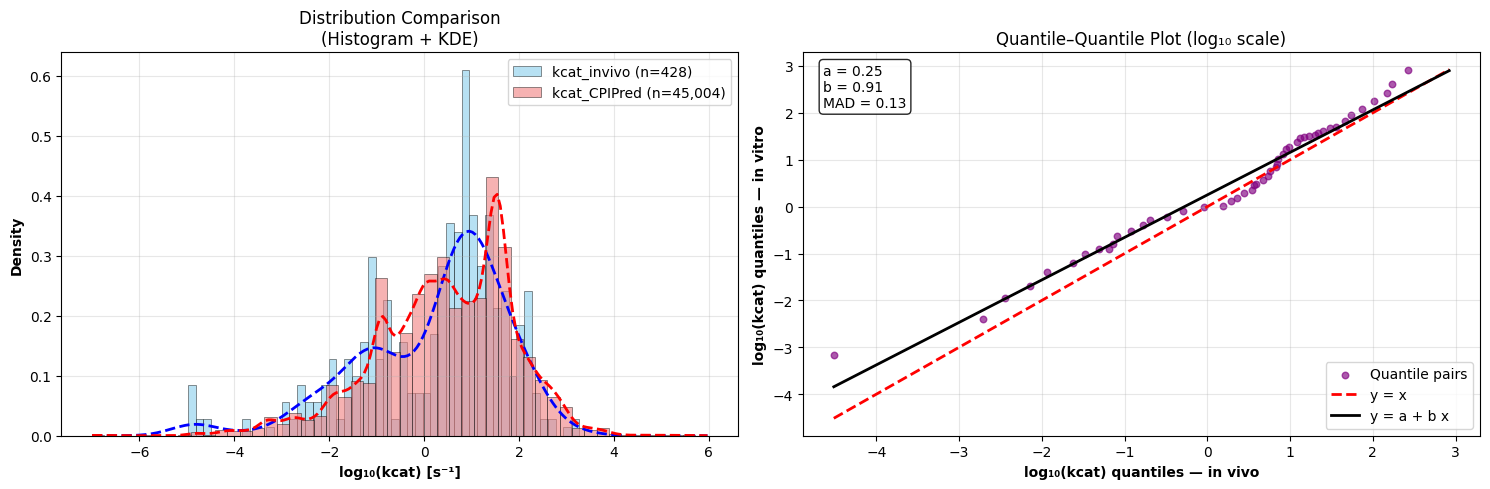

In [51]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CPIPred_df, "kcat_CPIPred", label1="kcat_invivo", label2="kcat_CPIPred")

### Interpretation of quantile-quantile plot

When comparing in vivo (var $A$) to in vitro (var $B$)

**Intercept $a$:**
- Vertical shift of the regression line.
- Captures the systematic location difference between the two distributions.
    - Here we are comparing all quantiles of the in vivo distribution against the in vitro distribution. This will give us a 'systematic' measure - a consistent shift
- $a=0$ - distributions are aligned, no shift
- $a<1$ - var $B$ is systematically lower than $A$
    - On raw scale, ratio ≈ $10^a$
- $a>1$ - var $B$ is systematically higher than $A$

**Slope $b$:**
- Tilt of the regression line.
- Reflects the relative spread/dispersion of the two distributions.
- $b=1$ - similar spread
- $b<1$ - var $B$ is more compressed
- $b>1$ - var $B$ is more spread

**MAD of residuals (Median Absolute Deviation):**

- Measure of goodness of fit between the observed quantile pairs and the fitted regression line.
- Smaller MAD: the shift and scaling (a and b) explain the differences consistently across quantiles.
- Larger MAD: deviations are uneven, often driven by heavy tails or outliers.


KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_invivo     kcat_CatPred   
--------------------------------------------------
Count                428             1,327          
Mean                 3.62e+01        7.23e+03       
Median               4.69e+00        1.43e+01       
Std Dev              1.46e+02        6.32e+04       
P10                  1.15e-02        1.20e-01       
P25                  1.44e-01        1.40e+00       
P75                  1.90e+01        9.20e+01       
P90                  7.50e+01        7.50e+02       
IQR (P25-P75)        1.89e+01        9.06e+01       
Geometric Mean       1.63e+00        1.19e+01       
Geometric Std        3.65e+01        3.60e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_invivo     kcat_CatPred   
--------------------------------------------------
Count        

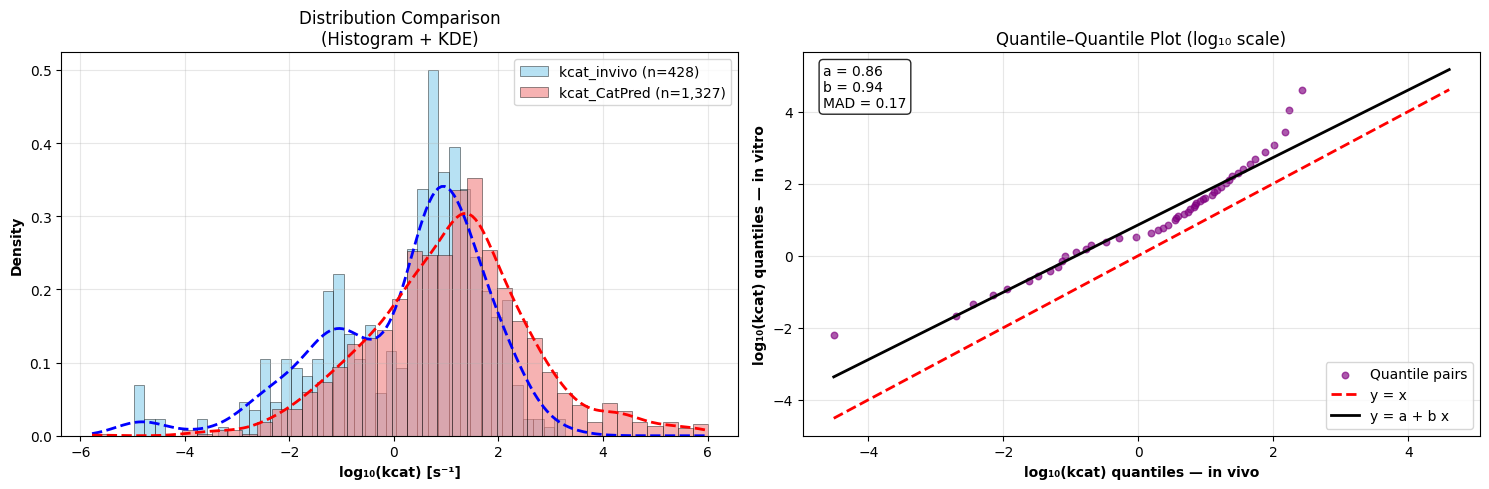

In [52]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CatPred_df, "kcat_CatPred", label1="kcat_invivo", label2="kcat_CatPred")

## ML Predicted kcats: CPI Pred

In [53]:
# Load iML1515 CPI Pred predictions
CPIPred_predictions_dir = os.path.join(data_dir, "processed", "kinGEMs_iML1515", "CPI_kcat_predictions.csv")
CPIPred_predictions_df = pd.read_csv(CPIPred_predictions_dir)

# Drop kcat column - it's a placeholder
CPIPred_predictions_df.drop(columns=['kcat'], inplace=True)

# Get kcat by averaging predictions across 5 folds
CPIPred_predictions_df["kcat_pred"] = CPIPred_predictions_df[
    ["pred_value_0", "pred_value_1", "pred_value_2", "pred_value_3", "pred_value_4"]
].mean(axis=1)

# Keep only kcat_pred column
CPIPred_predictions_df.rename(columns={"SEQ": "sequence", "CMPD_SMILES": "SMILES"}, inplace=True)
CPIPred_predictions_df = CPIPred_predictions_df[["sequence", "SMILES", "kcat_pred"]]

# There are multiple predictions for the same seq-SMILES pair, keep the largest (as done in kinGEMs)
CPIPred_predictions_df = (
    CPIPred_predictions_df
    .groupby(["sequence", "SMILES"], as_index=False)
    .max()
)

In [54]:
# Merge 
df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, CPIPred_predictions_df, on=["sequence", "SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_predicted
--------------------------------------------------
Count                428             6,336          
Mean                 3.62e+01        2.94e+02       
Median               4.69e+00        5.76e+00       
Std Dev              1.46e+02        1.16e+04       
P10                  1.15e-02        1.36e+00       
P25                  1.44e-01        2.89e+00       
P75                  1.90e+01        1.16e+01       
P90                  7.50e+01        2.48e+01       
IQR (P25-P75)        1.89e+01        8.71e+00       
Geometric Mean       1.63e+00        5.85e+00       
Geometric Std        3.65e+01        3.65e+00       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_predicted
--------------------------------------------------

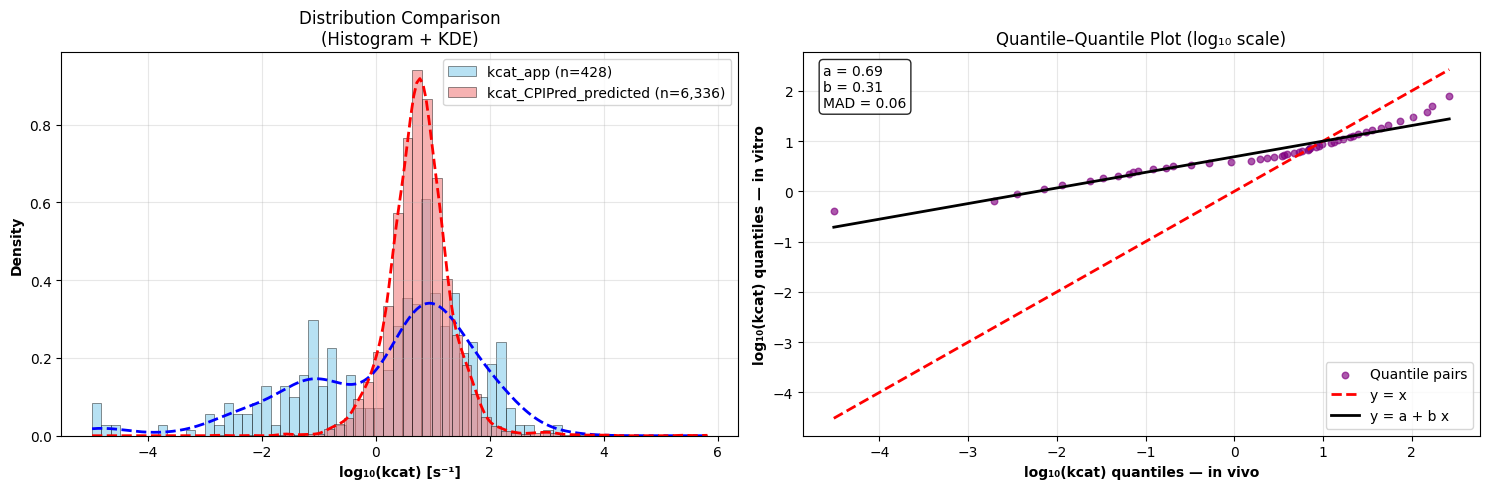

In [55]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CPIPred_predictions_df, "kcat_pred", label1="kcat_app", label2="kcat_CPIPred_predicted")

## (kinGEMs tuned) ML Predicted kcats: CPI Pred

In [56]:
# Load kinGEMs tuned iML1515 CPI Pred predictions
CPIPred_tuned_dir = os.path.join(data_dir, "processed", "kinGEMs_iML1515", "fluxes_kcat_tuned.csv")
CPIPred_tuned_df = pd.read_csv(CPIPred_tuned_dir)

# Keep only kcat_pred column
CPIPred_tuned_df.rename(columns={"SEQ": "sequence", "CMPD_SMILES": "SMILES"}, inplace=True)
CPIPred_tuned_df = CPIPred_tuned_df[["sequence", "SMILES", "kcat_mean"]]

# Keep the largest kcat_mean for each seq-SMILES pair
CPIPred_tuned_df = (
    CPIPred_tuned_df
    .groupby(["sequence", "SMILES"], as_index=False)
    .max()
)

In [57]:
# Merge 
df_fluxomics_homomeric = pd.merge(df_fluxomics_homomeric, CPIPred_tuned_df, on=["sequence", "SMILES"], how='left')

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_tuned
--------------------------------------------------
Count                428             6,190          
Mean                 3.62e+01        3.12e+02       
Median               4.69e+00        6.66e+00       
Std Dev              1.46e+02        1.17e+04       
P10                  1.15e-02        1.42e+00       
P25                  1.44e-01        3.08e+00       
P75                  1.90e+01        1.62e+01       
P90                  7.50e+01        5.28e+01       
IQR (P25-P75)        1.89e+01        1.31e+01       
Geometric Mean       1.63e+00        7.56e+00       
Geometric Std        3.65e+01        4.48e+00       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat_app        kcat_CPIPred_tuned
--------------------------------------------------
Count  

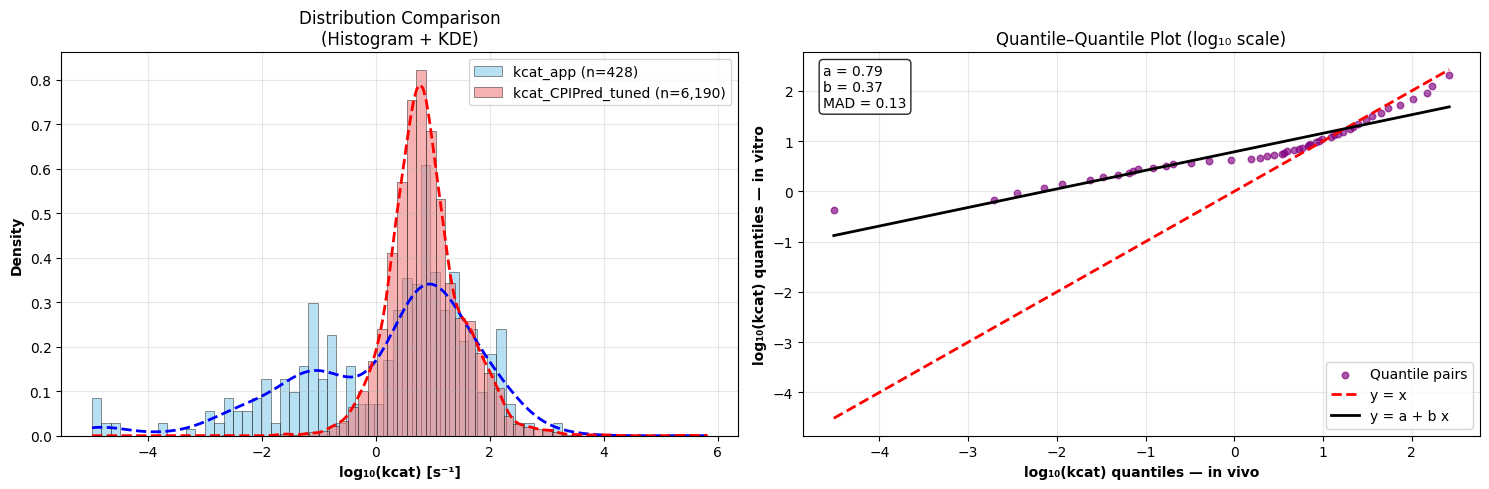

In [58]:
# Plot
from scripts.kcat_utils import compare_kcat_distribution

compare_kcat_distribution(df_fluxomics_homomeric, "kcat_app", CPIPred_tuned_df, "kcat_mean", label1="kcat_app", label2="kcat_CPIPred_tuned")